# 02 — Feature Engineering

**Goal:** Transform raw SPY returns into a rich feature matrix that captures the distributional properties of the return process across multiple time scales.

The features computed here serve two downstream purposes:
1. **Regime detection** — inputs to the HMM and k-means clusterers in notebook 03.
2. **Predictive model** — inputs to the Ridge regression in notebook 04.

---

### Feature groups
| Group | Features | Why it matters |
|---|---|---|
| Rolling statistics | mean, vol, realized vol | Trend and volatility regimes |
| Higher moments | skewness, kurtosis | Fat-tail / crisis signatures |
| Risk-adjusted | Sharpe ratio | Return quality per unit of risk |
| Momentum | cumulative return | Trend persistence |
| Structural | vol-of-vol, autocorrelation | Regime transition signals |
| AR features | lagged returns | Short-memory in the return process |

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import preprocess_pipeline
from features import build_feature_matrix, add_lagged_returns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})

# ── Load data ──────────────────────────────────────────────────────────────
data = preprocess_pipeline()
prices      = data['prices']
log_returns = data['log_returns']
drawdown    = data['drawdown']

print(f'Price series   : {prices.index[0].date()} → {prices.index[-1].date()}  ({len(prices):,} days)')
print(f'Return series  : {log_returns.index[0].date()} → {log_returns.index[-1].date()}  ({len(log_returns):,} observations)')

Price series   : 2005-01-03 → 2026-03-20  (5,337 days)
Return series  : 2005-01-04 → 2026-03-20  (5,336 observations)


## 1. Price and Return Overview

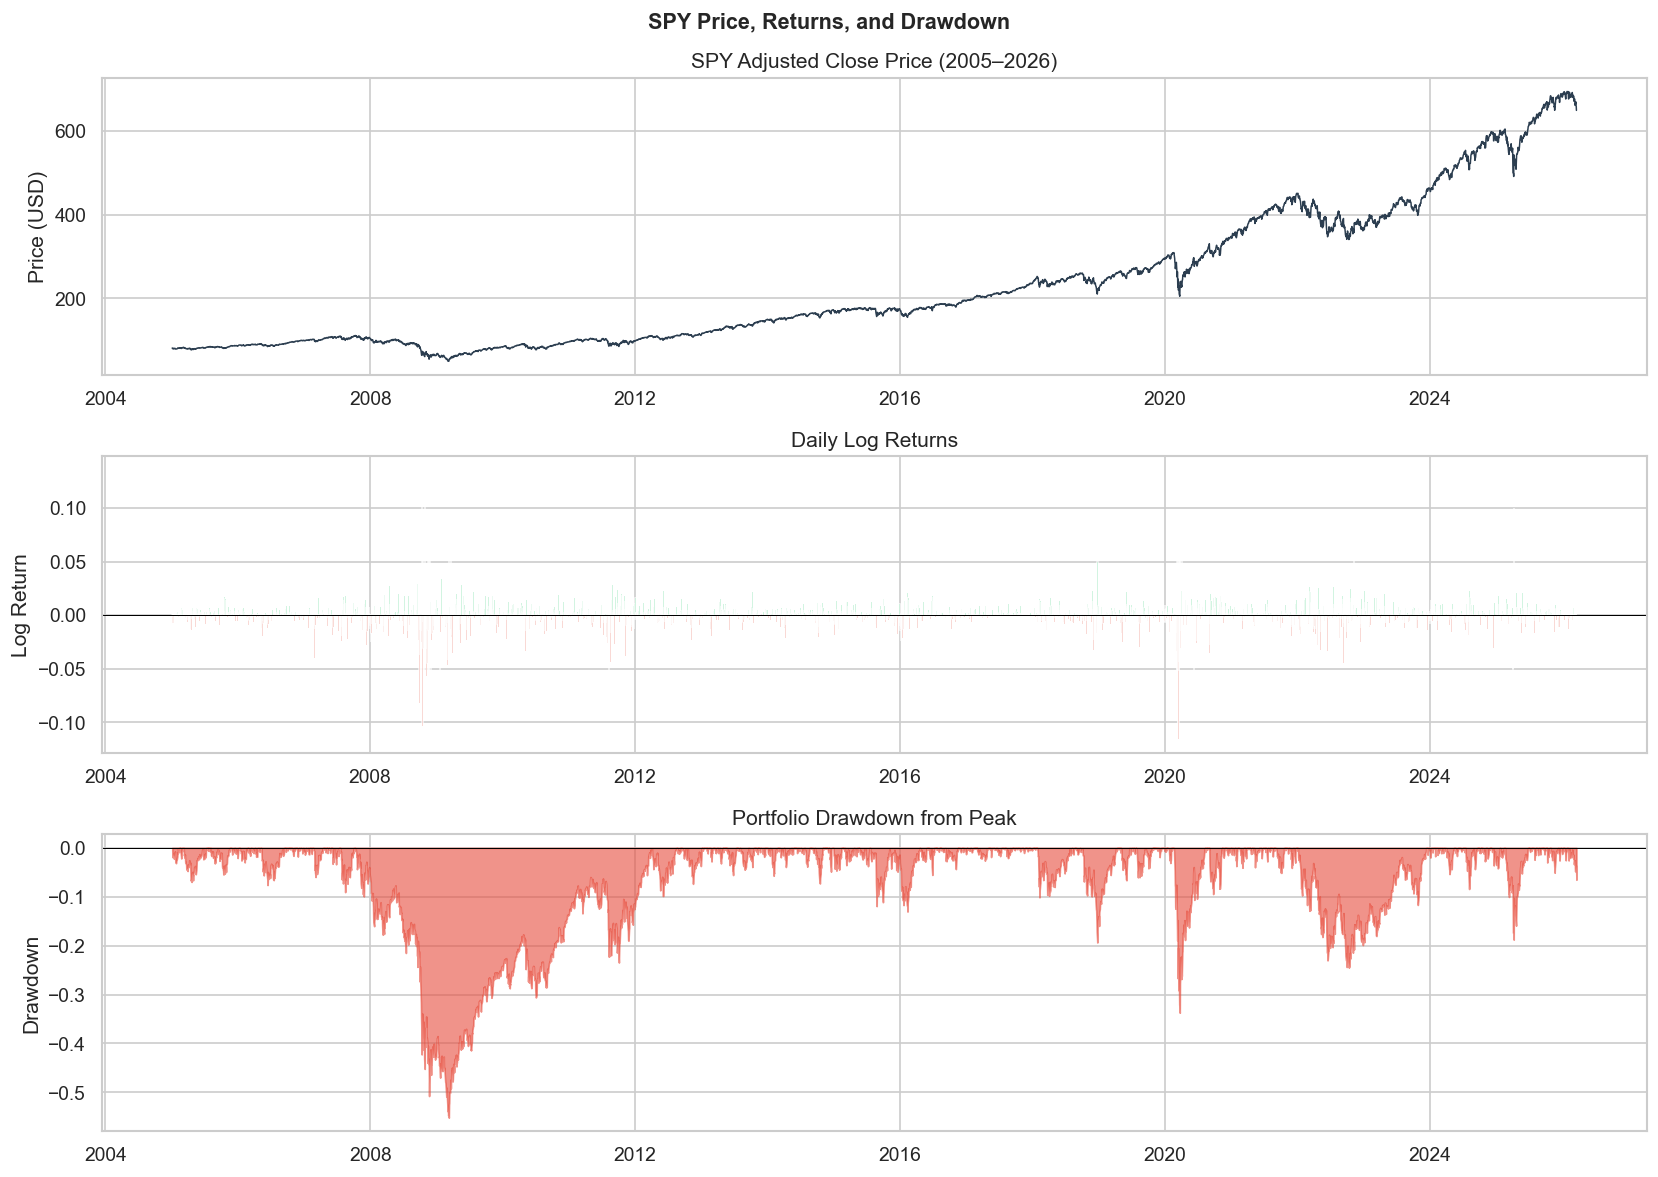

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# ── SPY Price ─────────────────────────────────────────────────────────────
axes[0].plot(prices.index, prices.values, color='#2c3e50', linewidth=0.9)
axes[0].set_title('SPY Adjusted Close Price (2005–2026)')
axes[0].set_ylabel('Price (USD)')

# ── Daily Log Returns ─────────────────────────────────────────────────────
axes[1].bar(log_returns.index, log_returns.values,
            color=np.where(log_returns.values >= 0, '#2ecc71', '#e74c3c'),
            width=1, alpha=0.7)
axes[1].set_title('Daily Log Returns')
axes[1].set_ylabel('Log Return')
axes[1].axhline(0, color='black', linewidth=0.6)

# ── Drawdown ──────────────────────────────────────────────────────────────
axes[2].fill_between(drawdown.index, drawdown['drawdown'].values,
                     0, color='#e74c3c', alpha=0.6)
axes[2].set_title('Portfolio Drawdown from Peak')
axes[2].set_ylabel('Drawdown')
axes[2].axhline(0, color='black', linewidth=0.6)

for ax in axes:
    import matplotlib.dates as mdates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('SPY Price, Returns, and Drawdown', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 2. Build the Feature Matrix

In [3]:
# Build features at 3 time scales: 20d (1 month), 60d (1 quarter), 252d (1 year)
features = build_feature_matrix(
    log_returns,
    windows=[20, 60, 252],
    include_vov=True,
    include_autocorr=True,   # set to False to skip the slow autocorr computation
)

# Add lagged returns (AR features)
features = add_lagged_returns(features, log_returns, lags=[1, 2, 3, 5])

print(f'Feature matrix : {features.shape[0]:,} rows  ×  {features.shape[1]} columns')
print(f'NaN rows before dropna: {features.isna().any(axis=1).sum():,}')

# Drop the warmup NaN rows for inspection
features_clean = features.dropna()
print(f'Clean rows (after dropna): {len(features_clean):,}')

features_clean.head(3)

Feature matrix : 5,336 rows  ×  27 columns
NaN rows before dropna: 251
Clean rows (after dropna): 5,085


,roll_mean_20d,roll_vol_20d,realized_vol_20d,roll_skew_20d,roll_kurt_20d,roll_sharpe_20d,momentum_20d,roll_mean_60d,roll_vol_60d,realized_vol_60d,...,roll_skew_252d,roll_kurt_252d,roll_sharpe_252d,momentum_252d,vov_20_60d,roll_autocorr_60d_lag1,return_lag1,return_lag2,return_lag3,return_lag5
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,0.051702,0.092891,0.025523,1.088540,3.033660,0.556585,0.003786,0.278486,0.108193,0.053046,...,-0.101784,0.022200,0.663063,0.065948,0.001992,-0.199805,-0.005446,-0.004463,0.002229,0.000553
2006-01-04,0.138086,0.093787,0.025869,0.893786,2.524928,1.472332,0.010683,0.283908,0.108344,0.053145,...,-0.105249,0.051092,0.831207,0.084316,0.001992,-0.162096,0.017436,-0.005446,-0.004463,-0.010229
2006-01-05,0.122131,0.093654,0.025807,0.932690,2.607882,1.304074,0.009405,0.322162,0.106486,0.052468,...,-0.114374,0.077482,0.906158,0.092562,0.001992,-0.175655,0.004725,0.017436,-0.005446,0.002229


## 3. Rolling Volatility — Multiple Time Scales

Volatility regime changes are most visible when overlaying short-term and long-term estimates.  
Key observation: **the 20-day vol spikes sharply during crises** (2008, 2020, 2025), while the **252-day vol rises more gradually** — a useful multi-scale signal.

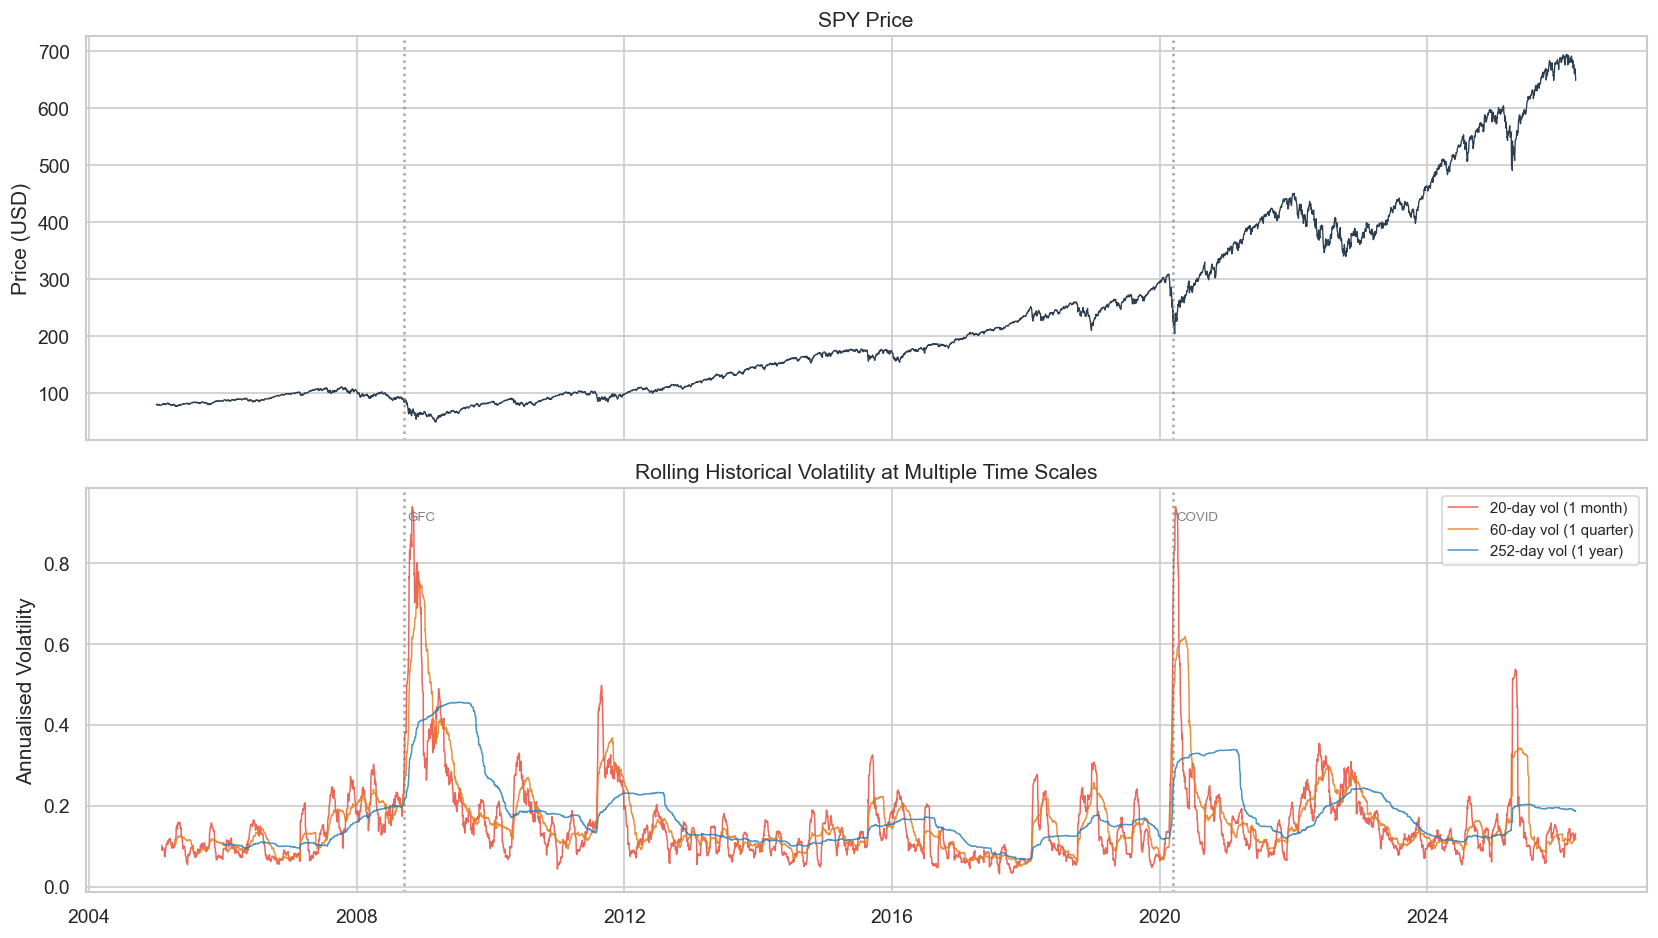

In [4]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Panel 1: Price ────────────────────────────────────────────────────────
axes[0].plot(prices.index, prices.values, color='#2c3e50', linewidth=0.8)
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('SPY Price')

# ── Panel 2: Rolling Volatility ───────────────────────────────────────────
colors = {'roll_vol_20d': '#e74c3c', 'roll_vol_60d': '#e67e22', 'roll_vol_252d': '#2980b9'}
labels = {'roll_vol_20d': '20-day vol (1 month)', 'roll_vol_60d': '60-day vol (1 quarter)', 'roll_vol_252d': '252-day vol (1 year)'}

for col, color in colors.items():
    axes[1].plot(features[col].index, features[col].values,
                 color=color, linewidth=0.9, alpha=0.85, label=labels[col])

axes[1].set_ylabel('Annualised Volatility')
axes[1].set_title('Rolling Historical Volatility at Multiple Time Scales')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Annotate key events
for ax in axes:
    ax.axvline(pd.Timestamp('2008-09-15'), color='grey', linestyle=':', alpha=0.7)
    ax.axvline(pd.Timestamp('2020-03-11'), color='grey', linestyle=':', alpha=0.7)

axes[1].text(pd.Timestamp('2008-10-01'), axes[1].get_ylim()[1]*0.92, 'GFC', fontsize=8, color='grey')
axes[1].text(pd.Timestamp('2020-04-01'), axes[1].get_ylim()[1]*0.92, 'COVID', fontsize=8, color='grey')

fig.tight_layout()
plt.show()

## 4. Higher Moments: Skewness and Kurtosis

- **Negative skewness** during crises: the left tail is heavier. Large losses are more common than large gains.
- **High kurtosis** during crises: the distribution has fatter tails than a Gaussian (extreme moves occur far more frequently than expected).

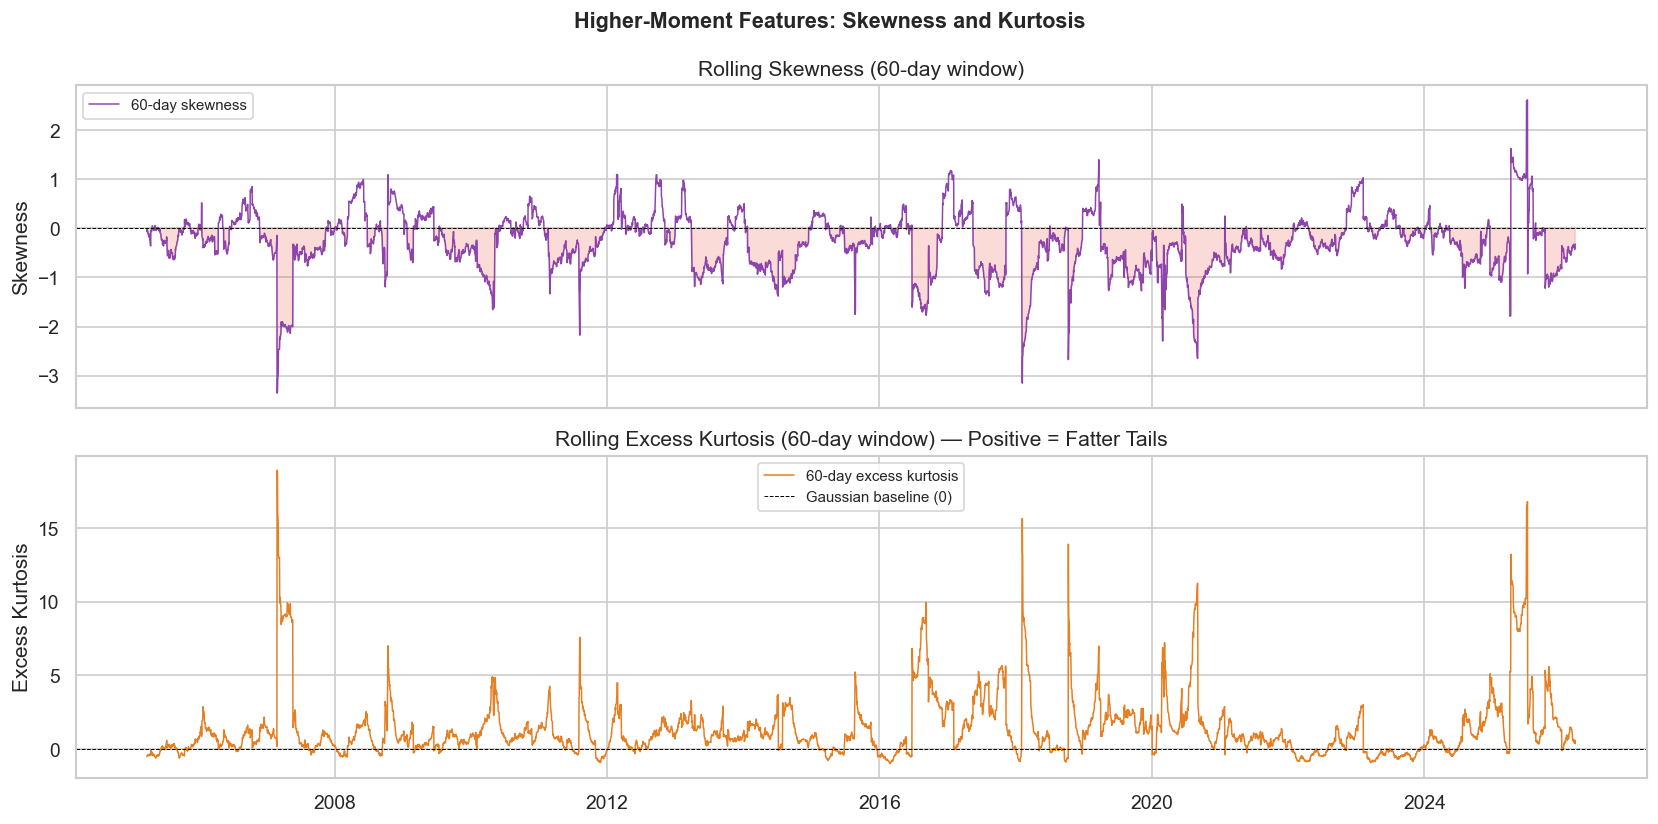

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# ── Skewness ──────────────────────────────────────────────────────────────
axes[0].plot(features['roll_skew_60d'].index, features['roll_skew_60d'].values,
             color='#8e44ad', linewidth=0.9, label='60-day skewness')
axes[0].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[0].set_ylabel('Skewness')
axes[0].set_title('Rolling Skewness (60-day window)')
axes[0].legend(fontsize=9)
axes[0].fill_between(features.index,
                     features['roll_skew_60d'].values, 0,
                     where=(features['roll_skew_60d'].values < 0),
                     alpha=0.2, color='#e74c3c', label='Negative skew')

# ── Kurtosis ──────────────────────────────────────────────────────────────
axes[1].plot(features['roll_kurt_60d'].index, features['roll_kurt_60d'].values,
             color='#e67e22', linewidth=0.9, label='60-day excess kurtosis')
axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--', label='Gaussian baseline (0)')
axes[1].set_ylabel('Excess Kurtosis')
axes[1].set_title('Rolling Excess Kurtosis (60-day window) — Positive = Fatter Tails')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Higher-Moment Features: Skewness and Kurtosis', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 5. Stationarity Testing (Augmented Dickey-Fuller)

Statistical models for regime detection assume the underlying signal is (or can be made) stationary.  
We test both the raw price and the log return series.

In [6]:
from statsmodels.tsa.stattools import adfuller

def adf_summary(series: pd.Series, name: str) -> None:
    """Run ADF test and print a human-readable summary."""
    result = adfuller(series.dropna(), autolag='AIC')
    stationary = result[1] < 0.05
    print(f'  {name:<25s}  ADF = {result[0]:+.4f}  p-value = {result[1]:.4f}  '
          f'→  {"STATIONARY ✓" if stationary else "NON-STATIONARY ✗"}')

print('\n── Augmented Dickey-Fuller Stationarity Tests ────────────────────────')
adf_summary(prices, 'SPY Close Price')
adf_summary(log_returns, 'Log Returns')
adf_summary(features['roll_vol_60d'].dropna(), 'Rolling Vol (60d)')
adf_summary(features['roll_vol_252d'].dropna(), 'Rolling Vol (252d)')
print()
print('Key insight: Raw prices are non-stationary; log returns and rolling vol are stationary.')
print('This confirms that log returns are the appropriate input for parametric drift tests.')


── Augmented Dickey-Fuller Stationarity Tests ────────────────────────
  SPY Close Price            ADF = +2.0300  p-value = 0.9987  →  NON-STATIONARY ✗
  Log Returns                ADF = -16.3694  p-value = 0.0000  →  STATIONARY ✓
  Rolling Vol (60d)          ADF = -6.2719  p-value = 0.0000  →  STATIONARY ✓
  Rolling Vol (252d)         ADF = -3.0112  p-value = 0.0339  →  STATIONARY ✓

Key insight: Raw prices are non-stationary; log returns and rolling vol are stationary.
This confirms that log returns are the appropriate input for parametric drift tests.


## 6. Feature Correlations

Understanding correlation structure helps identify redundant features and potential multicollinearity issues in the downstream Ridge regression.

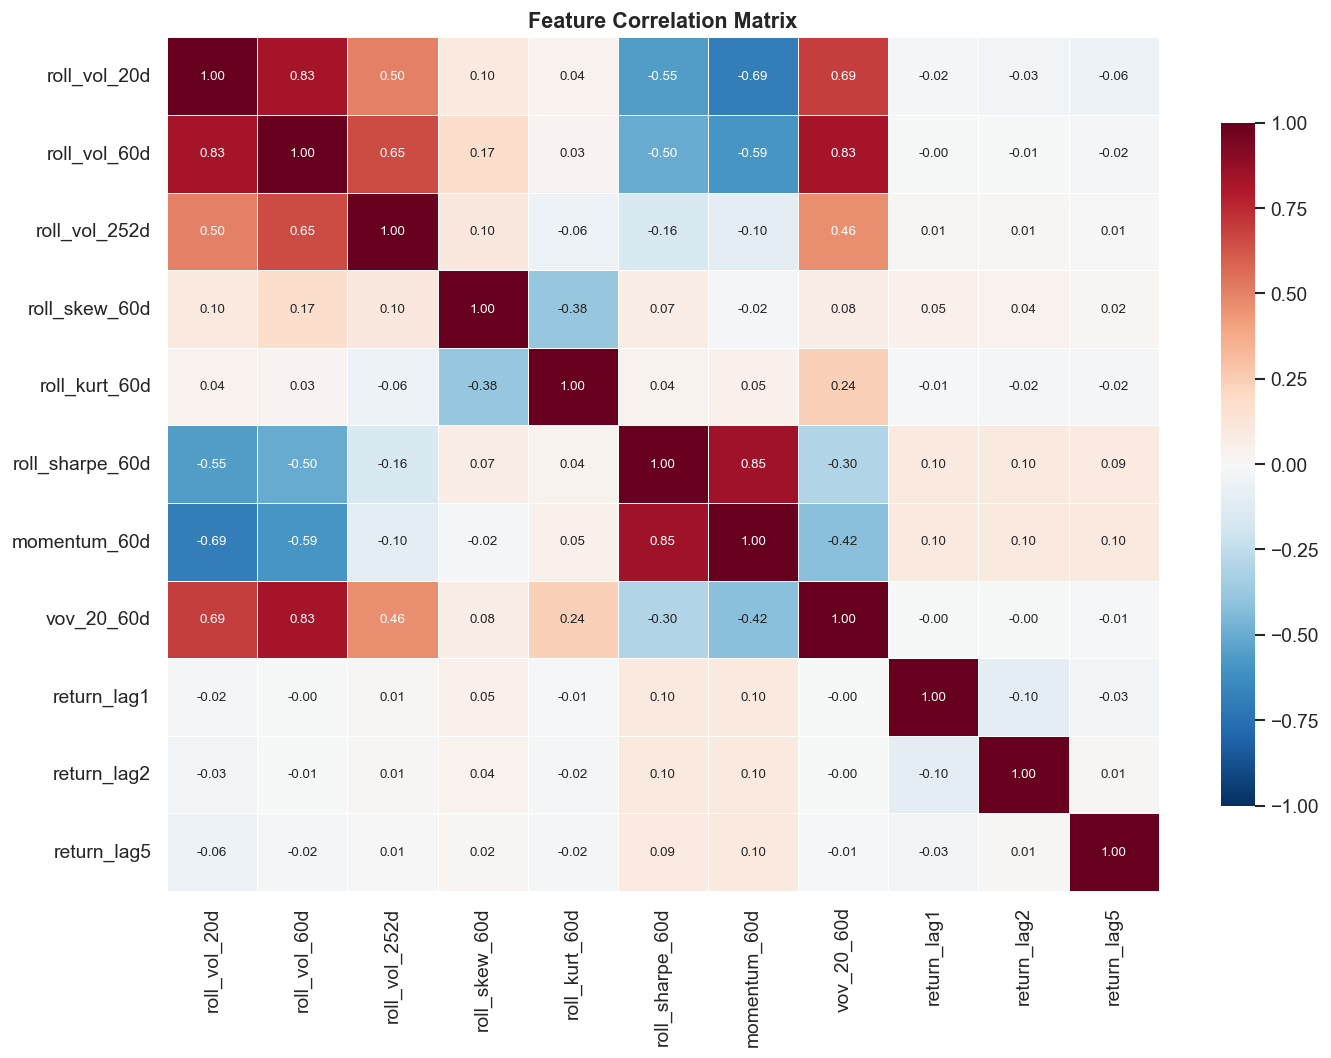

In [7]:
# Select a representative subset to keep the heatmap readable
selected_cols = [
    'roll_vol_20d', 'roll_vol_60d', 'roll_vol_252d',
    'roll_skew_60d', 'roll_kurt_60d',
    'roll_sharpe_60d', 'momentum_60d',
    'vov_20_60d',
    'return_lag1', 'return_lag2', 'return_lag5',
]

corr_matrix = features_clean[selected_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8},
    vmin=-1, vmax=1,
)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 7. Volatility-of-Volatility

Volatility-of-volatility (VoV) measures how much the volatility estimate *itself* is changing. Spikes in VoV often **precede** the main volatility surge during regime transitions, making it a potential early-warning signal.

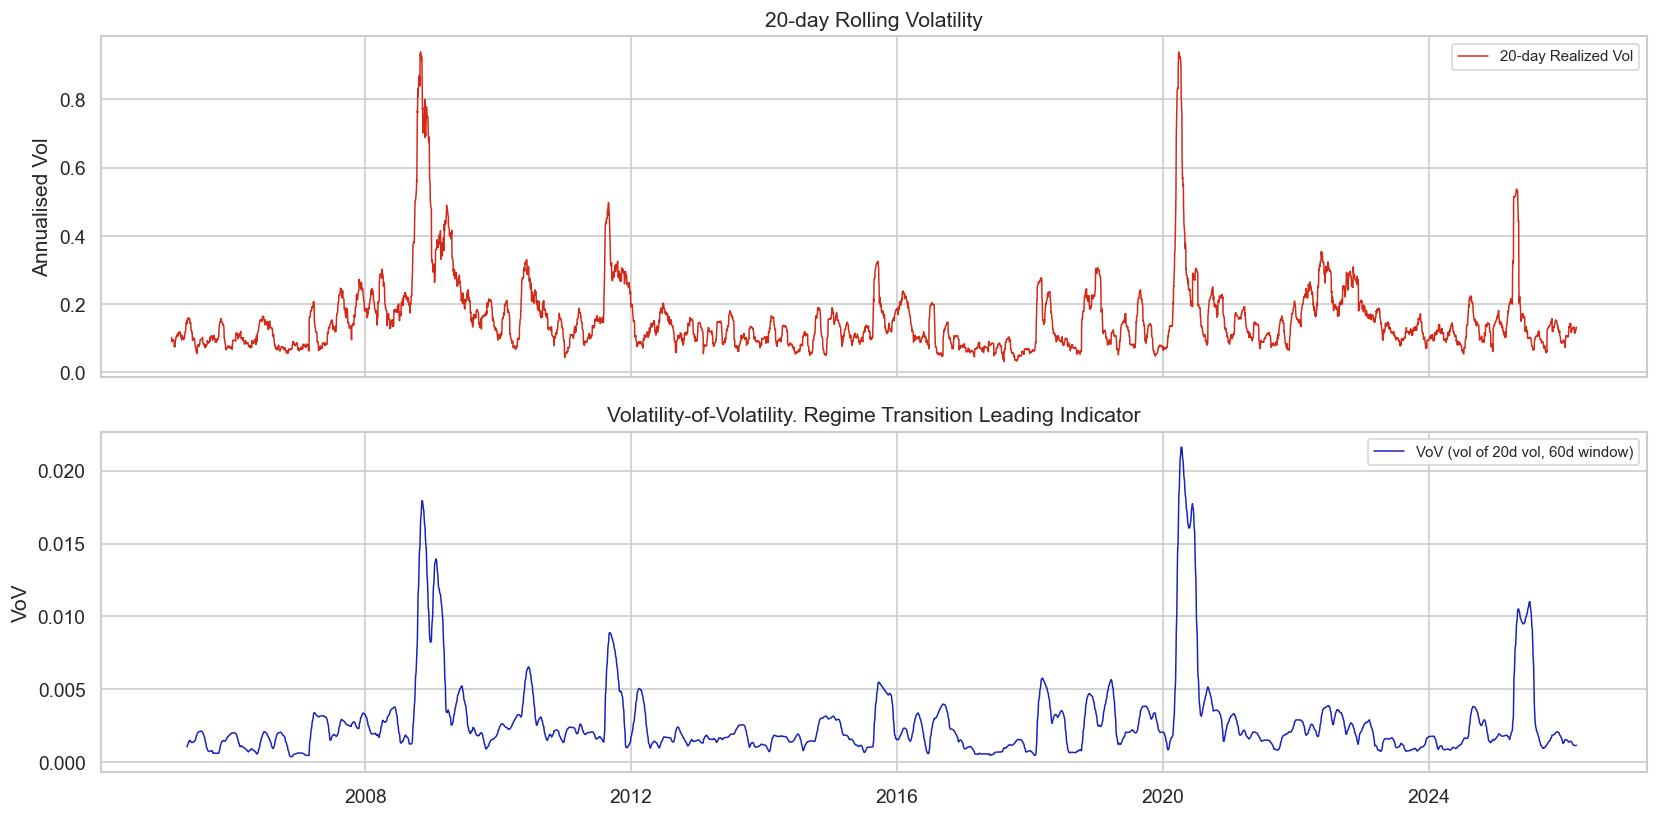

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(features['roll_vol_20d'].index, features['roll_vol_20d'].values,
             color="#d42916", linewidth=0.9, label='20-day Realized Vol')
axes[0].set_ylabel('Annualised Vol')
axes[0].set_title('20-day Rolling Volatility')
axes[0].legend(fontsize=9)

axes[1].plot(features['vov_20_60d'].index, features['vov_20_60d'].values,
             color="#1823b9", linewidth=0.9, label='VoV (vol of 20d vol, 60d window)')
axes[1].set_ylabel('VoV')
axes[1].set_title('Volatility-of-Volatility. Regime Transition Leading Indicator')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
plt.show()

## 8. Summary Statistics

Print descriptive statistics for the full feature matrix.

In [9]:
summary = features_clean.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary.columns = ['Mean', 'Std', 'Min', 'Q25', 'Median', 'Q75', 'Max']
print(f'Feature matrix shape: {features_clean.shape}')
summary.round(5)

Feature matrix shape: (5085, 27)


,Mean,Std,Min,Q25,Median,Q75,Max
roll_mean_20d,0.10161,0.58758,-4.67298,-0.13249,0.19534,0.42388,2.67186
roll_vol_20d,0.15889,0.11247,0.03186,0.09338,0.13148,0.18598,0.93971
realized_vol_20d,0.04463,0.03126,0.00923,0.02637,0.03665,0.05232,0.26038
roll_skew_20d,-0.13642,0.67988,-3.35976,-0.52803,-0.15368,0.27781,2.58338
roll_kurt_20d,0.62856,1.59840,-1.60059,-0.42757,0.27130,1.15937,13.36038
roll_sharpe_20d,1.60105,3.45107,-9.59204,-0.85908,1.64166,3.83618,13.20001
momentum_20d,0.00773,0.04648,-0.33072,-0.01195,0.01499,0.03368,0.22677
roll_mean_60d,0.10356,0.32222,-2.21633,-0.01704,0.15969,0.29199,1.40685
roll_vol_60d,0.16470,0.10214,0.04979,0.10847,0.13239,0.18934,0.75584
realized_vol_60d,0.08030,0.04954,0.02490,0.05310,0.06436,0.09196,0.36806


---
## Key Takeaways

1. **Non-stationarity** is confirmed in raw prices. Log returns and rolling stats are stationary (suitable inputs for drift tests).
2. **Volatility clustering** is highly visible across all windows: calm periods (2013–2019) alternate with crisis spikes (2008, 2020, 2025).
3. **Higher moments spike during crises**: negative skewness and high kurtosis are co-incident indicators of distributional stress.
4. **VoV precedes volatility surges**, making it a candidate leading indicator for regime-transition detection.
5. **Low autocorrelation** in lagged returns confirms near-random-walk behaviour in normal regimes.

-> **Next:** Notebook 03 applies HMM to formally identify and label regimes.